In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [22]:
indian_it = [
    "TCS.NS",
    "INFY.NS",
    "HCLTECH.NS",
    "WIPRO.NS",
    "TECHM.NS"
]


In [23]:
global_it = [
    "ACN",
    "CTSH",
    "CAP.PA",
    "IBM",
    "EPAM"
]


In [64]:
ai_leaders = [
    "AAPL",
    "MSFT",
    "NVDA",
    "GOOGL",
    "AMZN"
]


In [65]:
tickers = indian_it + global_it + ai_leaders


In [75]:


start = "2026-01-26"
end = "2026-02-14"

In [76]:
data_raw = yf.download(tickers, start=start, end=end)

# Extract Close prices
data = data_raw["Close"]

# Handle missing values
data = data.dropna(axis=1, how="all")
data = data.fillna(method="ffill")

data

[*********************100%***********************]  15 of 15 completed
C:\Users\rohan\AppData\Local\Temp\ipykernel_47428\1879579633.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="ffill")


Ticker,AAPL,ACN,AMZN,CAP.PA,CTSH,EPAM,GOOGL,HCLTECH.NS,IBM,INFY.NS,MSFT,NVDA,TCS.NS,TECHM.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,
2026-01-26,255.171234,280.709991,238.419998,136.399994,85.610001,220.440002,333.260010,NaN,294.650024,NaN,470.279999,186.470001,NaN,NaN,NaN
2026-01-27,258.028534,275.799988,244.679993,134.149994,84.650002,218.039993,334.549988,1720.199951,292.194031,1682.699951,480.579987,188.520004,3158.000000,1745.099976,234.800003
2026-01-28,256.200287,270.429993,243.009995,131.500000,83.300003,218.350006,336.010010,1729.599976,292.492371,1666.500000,481.630005,191.520004,3200.100098,1762.900024,237.350006
2026-01-29,258.038544,261.220001,241.729996,127.849998,82.449997,208.919998,338.250000,1721.599976,307.486847,1659.500000,433.500000,192.509995,3144.399902,1768.400024,239.800003
2026-01-30,259.237427,263.640015,239.300003,131.199997,82.059998,208.600006,338.000000,1695.599976,304.961273,1641.000000,430.290009,191.130005,3123.899902,1743.099976,236.899994
2026-02-02,269.757599,266.790009,242.960007,134.300003,82.910004,210.419998,343.690002,1676.800049,312.945740,1629.400024,423.369995,185.610001,3169.600098,1724.000000,242.300003
2026-02-03,269.228088,241.210007,238.619995,121.949997,74.500000,183.330002,339.709991,1695.300049,292.641510,1656.000000,411.209991,180.339996,3225.300049,1716.500000,242.690002
2026-02-04,276.231506,241.649994,232.990005,119.099998,76.709999,184.779999,333.040009,1621.800049,287.411316,1535.800049,414.190002,174.190002,2999.100098,1645.300049,233.339996
2026-02-05,275.652069,233.580002,222.690002,118.050003,76.839996,177.470001,331.250000,1610.000000,288.246582,1520.199951,393.670013,171.880005,2991.500000,1646.199951,233.389999


In [77]:
data = data.fillna(method="ffill")
data = data.dropna()


C:\Users\rohan\AppData\Local\Temp\ipykernel_47428\1409060995.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="ffill")


In [78]:
returns = data.pct_change().dropna()


In [79]:
def get_event_returns(global_date, india_date):
    event = {}
    
    for ticker in returns.columns:
        # Indian stocks end with .NS
        if ticker.endswith(".NS"):
            event[ticker] = returns.loc[india_date, ticker]
        else:
            event[ticker] = returns.loc[global_date, ticker]
    
    return pd.Series(event)


In [80]:
event1 = get_event_returns("2026-02-03", "2026-02-04")
event2 = get_event_returns("2026-02-11", "2026-02-12")


In [81]:
event_df = pd.DataFrame({
    "Event_1": event1,
    "Event_2": event2
})

event_df["Avg_Return"] = event_df.mean(axis=1)


In [82]:
def classify(ticker):
    if ticker in indian_it:
        return "Indian IT"
    elif ticker in global_it:
        return "Global IT Services"
    else:
        return "AI Leaders"

event_df["Group"] = event_df.index.map(classify)


In [83]:
group_summary = event_df.groupby("Group")["Avg_Return"].mean()
group_summary


Group
AI Leaders           -0.013323
Global IT Services   -0.079318
Indian IT            -0.053451
Name: Avg_Return, dtype: float64

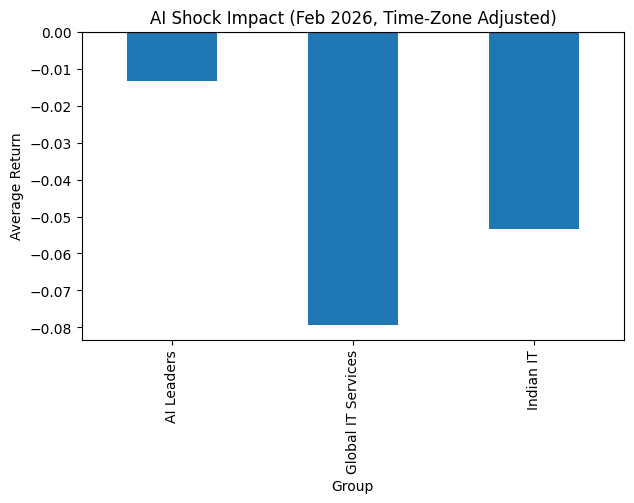

In [84]:
group_summary.plot(kind="bar", figsize=(7,4))
plt.axhline(0, color="black")
plt.title("AI Shock Impact (Feb 2026, Time-Zone Adjusted)")
plt.ylabel("Average Return")
plt.show()


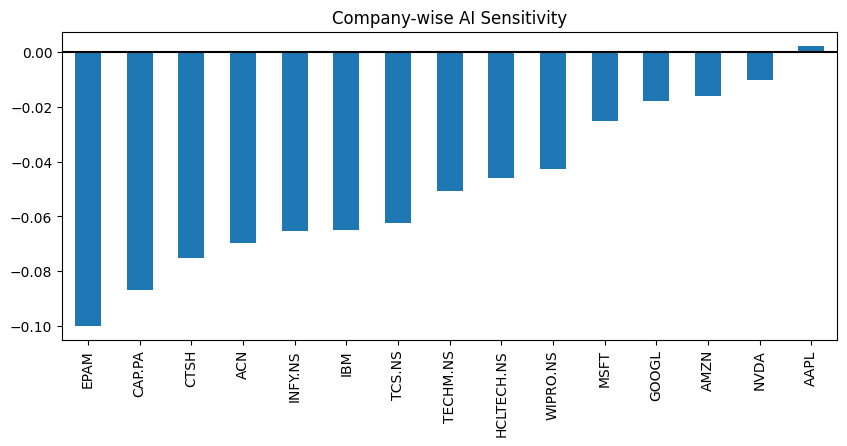

In [85]:
event_df.sort_values("Avg_Return")["Avg_Return"].plot(
    kind="bar",
    figsize=(10,4)
)
plt.axhline(0, color="black")
plt.title("Company-wise AI Sensitivity")
plt.show()


In [86]:
event_df.groupby("Group")["Avg_Return"].mean()


Group
AI Leaders           -0.013323
Global IT Services   -0.079318
Indian IT            -0.053451
Name: Avg_Return, dtype: float64

In [88]:
returns["SP500"] = yf.download("^GSPC", start=start, end=end)["Close"].pct_change()


[*********************100%***********************]  1 of 1 completed


In [90]:
returns["Global_IT_Index"] = returns[global_it].mean(axis=1)
returns["Indian_IT_Index"] = returns[indian_it].mean(axis=1)

global_abnormal = returns["Global_IT_Index"] - returns["SP500"]


In [91]:
event_df.head()


,Event_1,Event_2,Avg_Return,Group
AAPL,-0.001963,0.006650,0.002344,AI Leaders
ACN,-0.095881,-0.043303,-0.069592,Global IT Services
AMZN,-0.017863,-0.013916,-0.015889,AI Leaders
CAP.PA,-0.091958,-0.081866,-0.086912,Global IT Services
CTSH,-0.101435,-0.049081,-0.075258,Global IT Services


In [92]:
rd_data = {
    "ACN": 0.022,
    "CTSH": 0.01,
    "CAP.PA": 0.02,
    "IBM": 0.1119,
    "EPAM": 0.03,
}


In [93]:
rd_data.update({
    "TCS.NS": 0.01,
    "INFY.NS": 0.0062,
    "HCLTECH.NS": 0.014,
    "WIPRO.NS": 0.005,
    "TECHM.NS": 0.017,
})


In [94]:
rd_data.update({
    "AAPL": 0.083,
    "MSFT": 0.115,
    "NVDA": 0.10,
    "GOOGL": 0.15,
    "AMZN": 0.14,
})


In [95]:
rd_df = pd.DataFrame.from_dict(rd_data, orient="index", columns=["RD_Intensity"])

analysis_df = event_df.join(rd_df)

analysis_df.head()


,Event_1,Event_2,Avg_Return,Group,RD_Intensity
AAPL,-0.001963,0.006650,0.002344,AI Leaders,0.083
ACN,-0.095881,-0.043303,-0.069592,Global IT Services,0.022
AMZN,-0.017863,-0.013916,-0.015889,AI Leaders,0.140
CAP.PA,-0.091958,-0.081866,-0.086912,Global IT Services,0.020
CTSH,-0.101435,-0.049081,-0.075258,Global IT Services,0.010


In [96]:
rd_df = pd.DataFrame.from_dict(rd_data, orient="index", columns=["RD_Intensity"])

analysis_df = event_df.join(rd_df)

analysis_df.head()


,Event_1,Event_2,Avg_Return,Group,RD_Intensity
AAPL,-0.001963,0.006650,0.002344,AI Leaders,0.083
ACN,-0.095881,-0.043303,-0.069592,Global IT Services,0.022
AMZN,-0.017863,-0.013916,-0.015889,AI Leaders,0.140
CAP.PA,-0.091958,-0.081866,-0.086912,Global IT Services,0.020
CTSH,-0.101435,-0.049081,-0.075258,Global IT Services,0.010


In [97]:
analysis_df[["Avg_Return", "RD_Intensity"]].corr()


,Avg_Return,RD_Intensity
Avg_Return,1.000000,0.657939
RD_Intensity,0.657939,1.000000


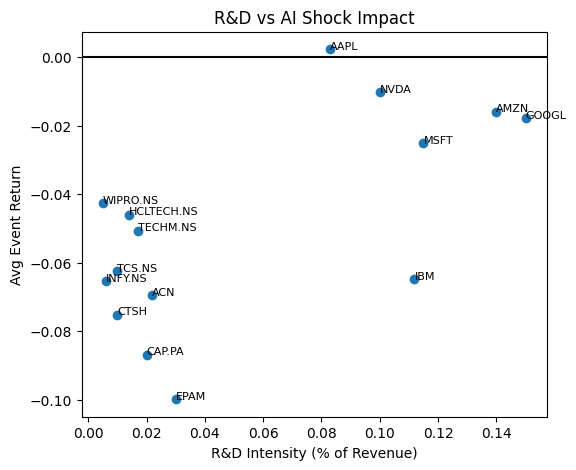

In [98]:
plt.figure(figsize=(6,5))
plt.scatter(analysis_df["RD_Intensity"], analysis_df["Avg_Return"])

for ticker in analysis_df.index:
    plt.text(
        analysis_df.loc[ticker, "RD_Intensity"],
        analysis_df.loc[ticker, "Avg_Return"],
        ticker,
        fontsize=8
    )

plt.axhline(0, color="black")
plt.xlabel("R&D Intensity (% of Revenue)")
plt.ylabel("Avg Event Return")
plt.title("R&D vs AI Shock Impact")
plt.show()


In [99]:
analysis_df["RD_Category"] = pd.cut(
    analysis_df["RD_Intensity"],
    bins=[0, 0.02, 0.08, 0.25],
    labels=["Low", "Medium", "High"]
)


C:\Users\rohan\AppData\Local\Temp\ipykernel_47428\2037961755.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("RD_Category")["Avg_Return"].mean().plot(kind="bar")


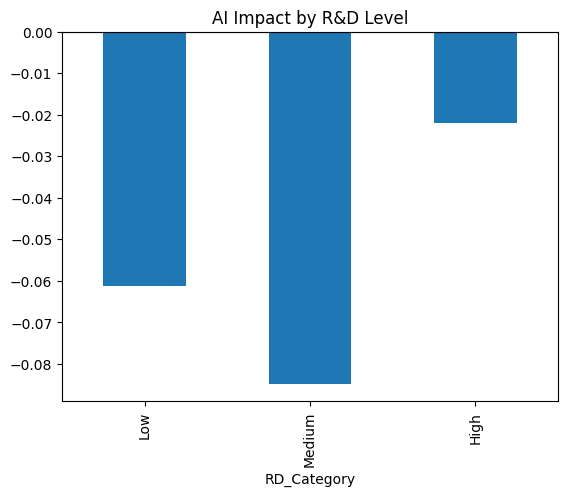

In [100]:
analysis_df.groupby("RD_Category")["Avg_Return"].mean().plot(kind="bar")
plt.axhline(0, color="black")
plt.title("AI Impact by R&D Level")
plt.show()
